<a href="https://colab.research.google.com/github/Mukty20/loan_prediction/blob/main/Loan_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
import json

df = pd.read_csv('Loan_default.csv')
print('Dataset shape:', df.shape)

Dataset shape: (255347, 18)


## Exploratory Data Analysis

In [7]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [8]:
df.tail()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0
255346,ZTH91CGL0B,62,22418,18481,636,113,2,6.73,12,0.48,Bachelor's,Unemployed,Divorced,Yes,No,Education,Yes,0


In [9]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [11]:
print('Missing values:\n', df.isnull().sum())

Missing values:
 LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [12]:
print('Target Distribution:')
print(df['Default'].value_counts())
print(f"\nDefault Rate: {df['Default'].mean()*100:.2f}%")

Target Distribution:
Default
0    225694
1     29653
Name: count, dtype: int64

Default Rate: 11.61%


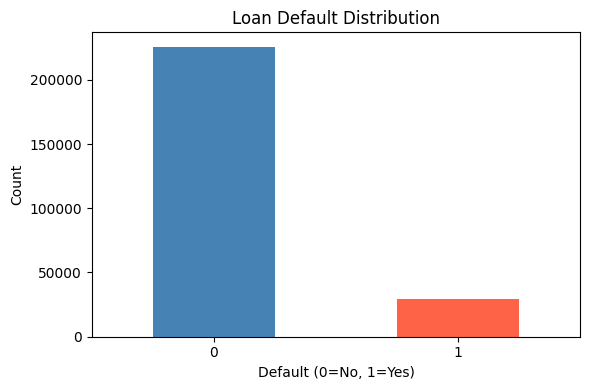

In [13]:
# Visualise target distribution
plt.figure(figsize=(6,4))
df['Default'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Loan Default Distribution')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

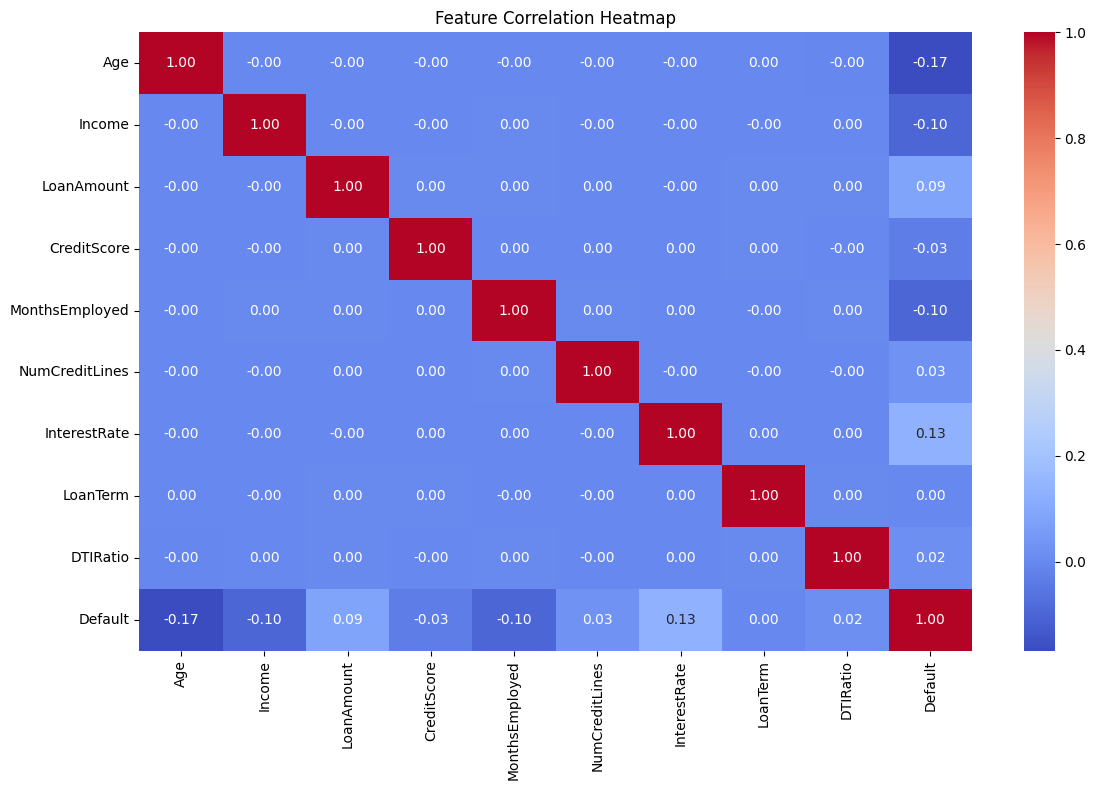

In [14]:
# Correlation heatmap (numeric columns only)
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Data Preprocessing

Encode categorical columns using LabelEncoder.

In [15]:
# Drop LoanID — not a feature
df = df.drop(columns=['LoanID'])

# Encode categorical columns
cat_cols = ['Education','EmploymentType','MaritalStatus','HasMortgage','HasDependents','LoanPurpose','HasCoSigner']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = list(le.classes_)
    print(f'{col}: {list(le.classes_)}')

print('\nEncoding complete.')

Education: ["Bachelor's", 'High School', "Master's", 'PhD']
EmploymentType: ['Full-time', 'Part-time', 'Self-employed', 'Unemployed']
MaritalStatus: ['Divorced', 'Married', 'Single']
HasMortgage: ['No', 'Yes']
HasDependents: ['No', 'Yes']
LoanPurpose: ['Auto', 'Business', 'Education', 'Home', 'Other']
HasCoSigner: ['No', 'Yes']

Encoding complete.


In [16]:
# Save encoder mappings for the app
with open('loan_encoders.json', 'w') as f:
    json.dump(encoders, f)
print('Encoders saved to loan_encoders.json')

Encoders saved to loan_encoders.json


## Train / Test Split

In [17]:
X = df.drop(columns='Default')
y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2)

print('X shape:', X.shape)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X shape: (255347, 16)
X_train shape: (204277, 16)
X_test shape: (51070, 16)


## Model Training — Random Forest

In [18]:
model = RandomForestClassifier(n_estimators=100, random_state=2, n_jobs=-1)
model.fit(X_train, y_train)
print('Training complete.')

Training complete.


## Model Evaluation

In [19]:
# Training accuracy
train_acc = accuracy_score(y_train, model.predict(X_train))
print(f'Accuracy on Training data: {train_acc:.4f}')

# Test accuracy
test_acc = accuracy_score(y_test, model.predict(X_test))
print(f'Accuracy on Test data:     {test_acc:.4f}')

Accuracy on Training data: 1.0000
Accuracy on Test data:     0.8859


In [20]:
# Classification report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['No Default','Default']))

              precision    recall  f1-score   support

  No Default       0.89      1.00      0.94     45139
     Default       0.61      0.05      0.09      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.51     51070
weighted avg       0.86      0.89      0.84     51070



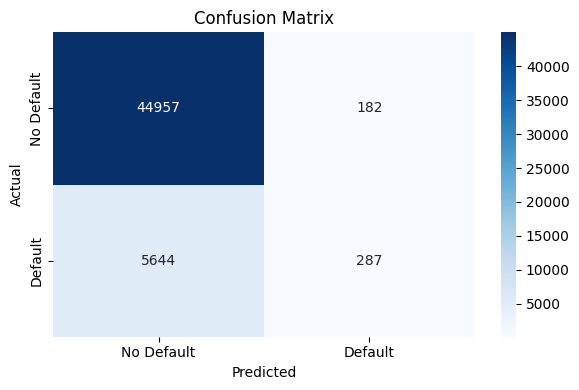

In [21]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

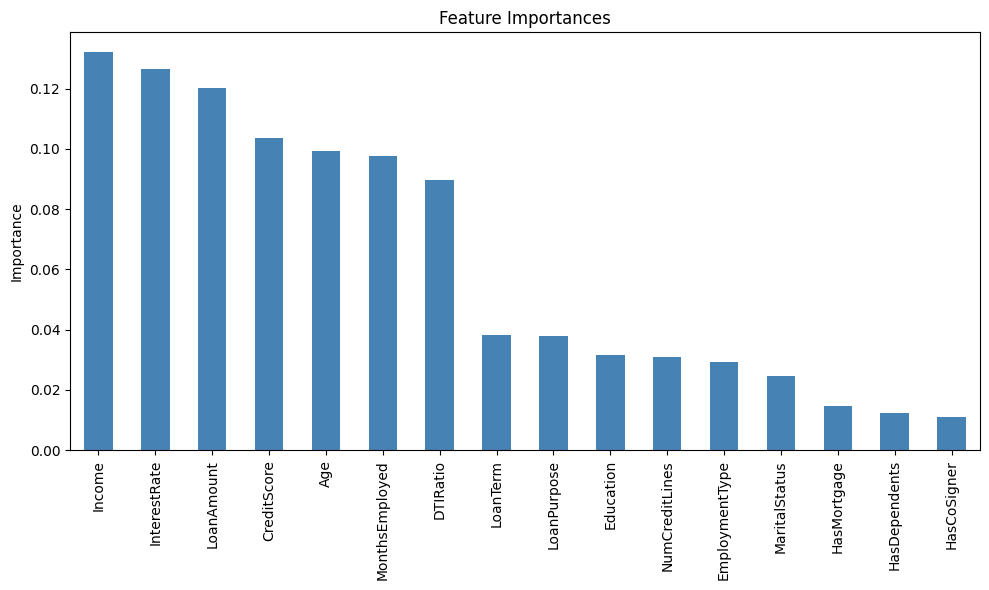

In [22]:
# Feature importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Feature Importances')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## Building a Predictive System

In [23]:
# Sample prediction
sample = {
    'Age': 35, 'Income': 60000, 'LoanAmount': 20000, 'CreditScore': 650,
    'MonthsEmployed': 24, 'NumCreditLines': 3, 'InterestRate': 8.5,
    'LoanTerm': 36, 'DTIRatio': 0.35,
    'Education': 'Bachelor\'s', 'EmploymentType': 'Full-time',
    'MaritalStatus': 'Single', 'HasMortgage': 'No',
    'HasDependents': 'No', 'LoanPurpose': 'Auto', 'HasCoSigner': 'No'
}

# Encode categoricals
sample_encoded = sample.copy()
for col, classes in encoders.items():
    sample_encoded[col] = classes.index(sample[col])

input_array = np.array(list(sample_encoded.values())).reshape(1, -1)
pred = model.predict(input_array)[0]
prob = model.predict_proba(input_array)[0]

print('Prediction:', 'WILL DEFAULT' if pred == 1 else 'WILL NOT DEFAULT')
print(f'Confidence: {max(prob)*100:.1f}%')

Prediction: WILL NOT DEFAULT
Confidence: 91.0%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Save the Trained Model

In [24]:
filename = 'loan-default-model.sav'
pickle.dump(model, open(filename, 'wb'))
print(f'Model saved as: {filename}')

Model saved as: loan-default-model.sav


In [25]:
# Verify it loads correctly
loaded_model = pickle.load(open('loan-default-model.sav', 'rb'))
print('Model loaded successfully.')
print('Features used:')
for col in X.columns:
    print(' -', col)

Model loaded successfully.
Features used:
 - Age
 - Income
 - LoanAmount
 - CreditScore
 - MonthsEmployed
 - NumCreditLines
 - InterestRate
 - LoanTerm
 - DTIRatio
 - Education
 - EmploymentType
 - MaritalStatus
 - HasMortgage
 - HasDependents
 - LoanPurpose
 - HasCoSigner


## Streamlit App



In [26]:
%%writefile app.py
import pickle
import json
import numpy as np
import streamlit as st

st.set_page_config(page_title='Loan Default Prediction', page_icon='🏦', layout='wide')

@st.cache_resource
def load_assets():
    model = pickle.load(open('loan-default-model.sav', 'rb'))
    with open('loan_encoders.json') as f:
        encoders = json.load(f)
    return model, encoders

try:
    model, encoders = load_assets()
except FileNotFoundError as e:
    st.error(f'Missing file: {e}')
    st.stop()

st.title('🏦 Loan Default Prediction')
st.markdown('Fill in the applicant details below and click **Predict** to assess default risk.')
st.divider()

col1, col2, col3 = st.columns(3)

with col1:
    age             = st.number_input('Age', 18, 100, 35)
    income          = st.number_input('Annual Income ($)', 1000, 1000000, 60000, step=1000)
    loan_amount     = st.number_input('Loan Amount ($)', 500, 1000000, 20000, step=500)
    credit_score    = st.number_input('Credit Score', 300, 850, 650)
    months_employed = st.number_input('Months Employed', 0, 600, 24)

with col2:
    num_credit      = st.number_input('Number of Credit Lines', 0, 50, 3)
    interest_rate   = st.number_input('Interest Rate (%)', 0.0, 40.0, 8.5, step=0.1)
    loan_term       = st.selectbox('Loan Term (months)', [12, 24, 36, 48, 60])
    dti_ratio       = st.number_input('DTI Ratio', 0.0, 1.0, 0.35, step=0.01)
    education       = st.selectbox('Education', encoders['Education'])

with col3:
    employment_type = st.selectbox('Employment Type', encoders['EmploymentType'])
    marital_status  = st.selectbox('Marital Status', encoders['MaritalStatus'])
    has_mortgage    = st.selectbox('Has Mortgage?', encoders['HasMortgage'])
    has_dependents  = st.selectbox('Has Dependents?', encoders['HasDependents'])
    loan_purpose    = st.selectbox('Loan Purpose', encoders['LoanPurpose'])
    has_cosigner    = st.selectbox('Has Co-Signer?', encoders['HasCoSigner'])

st.divider()

if st.button('🔍 Predict Default Risk', use_container_width=True, type='primary'):
    features = [
        age, income, loan_amount, credit_score, months_employed,
        num_credit, interest_rate, loan_term, dti_ratio,
        encoders['Education'].index(education),
        encoders['EmploymentType'].index(employment_type),
        encoders['MaritalStatus'].index(marital_status),
        encoders['HasMortgage'].index(has_mortgage),
        encoders['HasDependents'].index(has_dependents),
        encoders['LoanPurpose'].index(loan_purpose),
        encoders['HasCoSigner'].index(has_cosigner),
    ]
    input_array = np.array(features).reshape(1, -1)
    prediction  = model.predict(input_array)[0]
    probability = model.predict_proba(input_array)[0]

    if prediction == 1:
        st.error(f'⚠️ HIGH RISK — This applicant is likely to DEFAULT (confidence: {probability[1]*100:.1f}%)')
    else:
        st.success(f'✅ LOW RISK — This applicant is unlikely to default (confidence: {probability[0]*100:.1f}%)')

    with st.expander('📊 View Input Summary'):
        import pandas as pd
        labels = ['Age','Income','Loan Amount','Credit Score','Months Employed',
                  'Credit Lines','Interest Rate','Loan Term','DTI Ratio',
                  'Education','Employment','Marital Status','Has Mortgage',
                  'Has Dependents','Loan Purpose','Has Co-Signer']
        raw_vals = [age,income,loan_amount,credit_score,months_employed,
                    num_credit,interest_rate,loan_term,dti_ratio,
                    education,employment_type,marital_status,
                    has_mortgage,has_dependents,loan_purpose,has_cosigner]
        st.table(pd.DataFrame({'Feature': labels, 'Value': raw_vals}))


Writing app.py
